# EEG Seizure Prediction — Complete Pipeline (VAE-GAN)
### Paper: *A Generative Model to Synthesize EEG Data for Epileptic Seizure Prediction* (IEEE TNSRE 2021)
### Generative Model: **VAE-GAN** (Variational Autoencoder + GAN)
---

In [1]:
# ============================================================
# CELL 1: Paths & Project Setup — FIXED (skip G: drive check)
# ============================================================
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd() / "Paper1_Reproduction"
PROJECT_ROOT = str(PROJECT_ROOT)

DATASET_ROOT = Path(r"G:\My Drive\paper1_dcgan\chbmit")
SAVE_MODEL   = os.path.join(PROJECT_ROOT, "03_models")

# Create all required folders
folders = [
    "01_dataset/metadata",
    "02_preprocessed/preictal",
    "02_preprocessed/interictal", 
    "03_models",
    "04_generated",
    "05_results/figures",
    "05_results/tables",
]
for f in folders:
    os.makedirs(os.path.join(PROJECT_ROOT, f), exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATASET_ROOT :", DATASET_ROOT)
# Skip DATASET_ROOT.exists() — G: drive slow ho sakta hai
print("Setup complete!")


PROJECT_ROOT : C:\Users\SHIVA\Downloads\Paper1_Reproduction-20260629T171224Z-3-001\Paper1_Reproduction
DATASET_ROOT : G:\My Drive\paper1_dcgan\chbmit
Setup complete!


In [2]:
# ============================================================
# CELL 2: Imports
# ============================================================
import os, re, ast, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import mne
from tqdm import tqdm
from scipy.signal import stft, butter, filtfilt
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## Section 1 — Build Metadata from EDF Files
---

In [4]:
# ============================================================
# CELL 3: Scan EDF Files & Build Metadata
# ============================================================
patient_folders = sorted([
    p for p in DATASET_ROOT.iterdir()
    if p.is_dir() and p.name.startswith("chb")
])
print(f"Total patients: {len(patient_folders)}")

records = []
for patient in patient_folders:
    for edf in sorted(patient.glob("*.edf")):
        records.append({
            "patient": patient.name,
            "edf_file": edf.name,
            "num_seizures": 0,
            "start_sec": None,
            "end_sec": None
        })

metadata_df = pd.DataFrame(records)
print(f"Total EDF files: {len(metadata_df)}")
metadata_df.head()

Total patients: 24
Total EDF files: 686


,patient,edf_file,num_seizures,start_sec,end_sec
0,chb01,chb01_01.edf,0,None,None
1,chb01,chb01_02.edf,0,None,None
2,chb01,chb01_03.edf,0,None,None
3,chb01,chb01_04.edf,0,None,None
4,chb01,chb01_05.edf,0,None,None


In [9]:
# ============================================================
# CELL 4: Parse Summary Files → Fill Seizure Times
# ============================================================
for patient in patient_folders:
    summary_file = patient / f"{patient.name}-summary.txt"
    if not summary_file.exists():
        continue

    with open(summary_file, "r", encoding="utf-8", errors="ignore") as f:
        lines = [l.strip() for l in f.readlines()]

    current_file = None
    starts, ends = [], []
    i = 0
    while i < len(lines):
        line = lines[i]
        if line.startswith("File Name:"):
            if current_file and starts:
                idx = metadata_df[
                    (metadata_df.patient == patient.name) &
                    (metadata_df.edf_file == current_file)
                ].index
                if len(idx):
                    metadata_df.loc[idx[0], "num_seizures"] = len(starts)
                    metadata_df.loc[idx[0], "start_sec"] = str(starts)
                    metadata_df.loc[idx[0], "end_sec"] = str(ends)
            current_file = line.split(":")[-1].strip()
            starts, ends = [], []
        elif "Seizure" in line and "Start Time" in line:
            try:
                starts.append(int(re.findall(r'\d+', line)[-1]))
            except:
                pass
        elif "Seizure" in line and "End Time" in line:
            try:
                ends.append(int(re.findall(r'\d+', line)[-1]))
            except:
                pass
        i += 1
    # Save last file
    if current_file and starts:
        idx = metadata_df[
            (metadata_df.patient == patient.name) &
            (metadata_df.edf_file == current_file)
        ].index
        if len(idx):
            metadata_df.loc[idx[0], "num_seizures"] = len(starts)
            metadata_df.loc[idx[0], "start_sec"] = str(starts)
            metadata_df.loc[idx[0], "end_sec"] = str(ends)

seizure_rows = metadata_df[metadata_df.num_seizures > 0]
print(f"EDF files with seizures: {len(seizure_rows)}")
print(f"Total seizure events: {metadata_df.num_seizures.sum()}")

metadata_path = os.path.join(PROJECT_ROOT, "01_dataset/metadata/chbmit_metadata.csv")
metadata_df.to_csv(metadata_path, index=False)
print("Saved:", metadata_path)
metadata_df[metadata_df.num_seizures > 0].head(10)



EDF files with seizures: 141
Total seizure events: 198
Saved: C:\Users\SHIVA\Downloads\Paper1_Reproduction-20260629T171224Z-3-001\Paper1_Reproduction\01_dataset/metadata/chbmit_metadata.csv


,patient,edf_file,num_seizures,start_sec,end_sec
2,chb01,chb01_03.edf,1,[2996],[3036]
3,chb01,chb01_04.edf,1,[1467],[1494]
14,chb01,chb01_15.edf,1,[1732],[1772]
15,chb01,chb01_16.edf,1,[1015],[1066]
17,chb01,chb01_18.edf,1,[1720],[1810]
20,chb01,chb01_21.edf,1,[327],[420]
25,chb01,chb01_26.edf,1,[1862],[1963]
57,chb02,chb02_16+.edf,1,[2972],[3053]
58,chb02,chb02_16.edf,1,[130],[212]
61,chb02,chb02_19.edf,1,[3369],[3378]


In [7]:
# ============================================================
# CELL 5: Save Metadata CSV
# ============================================================
metadata_path = os.path.join(PROJECT_ROOT, "01_dataset/metadata/chbmit_metadata.csv")
metadata_df.to_csv(metadata_path, index=False)
print("Saved:", metadata_path)
metadata_df[metadata_df.num_seizures > 0]

Saved: C:\Users\SHIVA\Downloads\Paper1_Reproduction-20260629T171224Z-3-001\Paper1_Reproduction\01_dataset/metadata/chbmit_metadata.csv


,patient,edf_file,num_seizures,start_sec,end_sec
2,chb01,chb01_03.edf,1,[2996],[3036]
3,chb01,chb01_04.edf,1,[1467],[1494]
14,chb01,chb01_15.edf,1,[1732],[1772]
15,chb01,chb01_16.edf,1,[1015],[1066]
17,chb01,chb01_18.edf,1,[1720],[1810]
...,...,...,...,...,...
676,chb24,chb24_13.edf,1,[3288],[3304]
677,chb24,chb24_14.edf,1,[1939],[1966]
678,chb24,chb24_15.edf,1,[3552],[3569]
680,chb24,chb24_17.edf,1,[3515],[3581]


# ============================================================
# CELL 7: Load EDF Function (Retry-safe for network drops/resets)
# ============================================================
import time

def load_edf(patient, edf_file, retries=15, delay=20):
    """
    Loads EDF file from Google Drive.
    If the network drops (like midnight data limit reset), 
    it retries up to 15 times (5 minutes) before failing.
    """
    path = DATASET_ROOT / patient / edf_file
    for i in range(retries):
        try:
            raw = mne.io.read_raw_edf(str(path), preload=True, verbose=False)
            raw.pick_types(eeg=True)
            signal = raw.get_data().astype("float32")
            fs = int(raw.info["sfreq"])
            return signal, fs, raw.ch_names
        except Exception as e:
            if i < retries - 1:
                print(f"\n[RETRY {i+1}/{retries}] G: Drive offline/disconnected: {e}. Waiting {delay}s for reconnect...")
                time.sleep(delay)
            else:
                raise e


In [6]:
# ============================================================
# CELL 6: EDF Timeline (for cross-file preictal extraction)
# ============================================================
edf_records = []
for patient in patient_folders:
    edf_files = sorted(
        patient.glob("*.edf"),
        key=lambda x: int(re.findall(r'_(\d+)', x.stem)[0])
    )
    for edf in edf_files:
        edf_records.append({
            "patient": patient.name,
            "edf_file": edf.name,
            "path": str(edf)
        })

edf_table = pd.DataFrame(edf_records)
edf_lookup = {(r.patient, r.edf_file): r.path for _, r in edf_table.iterrows()}
print("EDF files in lookup:", len(edf_lookup))

def previous_edf(patient, edf_file):
    num = int(re.findall(r'_(\d+)', edf_file)[0])
    if num == 1:
        return None
    prev = f"{patient}_{num-1:02d}.edf"
    return prev if (patient, prev) in edf_lookup else None

EDF files in lookup: 686


In [3]:
# ============================================================
# CELL 7: Load EDF Function
# ============================================================
def load_edf(patient, edf_file):
    path = DATASET_ROOT / patient / edf_file
    raw = mne.io.read_raw_edf(str(path), preload=True, verbose=False)
    raw.pick_types(eeg=True)
    signal = raw.get_data().astype("float32")
    fs = int(raw.info["sfreq"])
    return signal, fs, raw.ch_names

In [4]:
# ============================================================
# CELL 8: Butterworth Bandstop Filter (remove 60Hz powerline noise)
# Paper: remove 57-63 Hz and 117-123 Hz for CHB-MIT (60Hz grid)
# ============================================================
def apply_bandstop(signal, low, high, fs, order=4):
    nyq = fs / 2
    low_n = low / nyq
    high_n = high / nyq
    b, a = butter(order, [low_n, high_n], btype='bandstop')
    return filtfilt(b, a, signal, axis=1).astype("float32")

In [5]:
# ============================================================
# CELL 9: Extract 10-min Preictal Window
# Paper: 10 min preictal window, SPH=10min
# Handles cross-file (uses previous EDF if needed)
# ============================================================
PREICTAL_SECONDS = 600  # 10 minutes

def extract_preictal(patient, edf_file, seizure_start):
    signal, fs, ch_curr = load_edf(patient, edf_file)
    required_samples = PREICTAL_SECONDS * fs
    seizure_sample = int(seizure_start * fs)
    start_sample = seizure_sample - required_samples

    # Case 1: entire preictal in current EDF
    if start_sample >= 0:
        preictal = signal[:, start_sample:seizure_sample]
        if preictal.shape[1] != required_samples:
            return None, fs
        return preictal, fs

    # Case 2: need previous EDF
    prev_file = previous_edf(patient, edf_file)
    if prev_file is None:
        return None, fs

    prev_signal, _, ch_prev = load_edf(patient, prev_file)

    # Common channels only
    common = [ch for ch in ch_curr if ch in ch_prev]
    if not common:
        return None, fs

    curr_idx = [ch_curr.index(c) for c in common]
    prev_idx = [ch_prev.index(c) for c in common]
    signal = signal[curr_idx]
    prev_signal = prev_signal[prev_idx]

    current_part = signal[:, :seizure_sample]
    remaining = required_samples - current_part.shape[1]

    if remaining <= 0:
        return current_part[:, -required_samples:], fs
    if remaining > prev_signal.shape[1]:
        return None, fs

    preictal = np.concatenate([prev_signal[:, -remaining:], current_part], axis=1)
    if preictal.shape[1] != required_samples:
        return None, fs
    return preictal, fs

In [6]:
# ============================================================
# CELL 10: Extract Interictal Window
# Paper: interictal = at least 4 hours away from any seizure
# ============================================================
INTERICTAL_SECONDS = 600  # 10 minutes same as preictal

def extract_interictal(patient, edf_file, start_sec):
    """Extract a 10-min interictal segment from given start_sec."""
    signal, fs, _ = load_edf(patient, edf_file)
    start_sample = int(start_sec * fs)
    end_sample = start_sample + INTERICTAL_SECONDS * fs
    if end_sample > signal.shape[1]:
        return None, fs
    return signal[:, start_sample:end_sample].astype("float32"), fs

In [7]:
# ============================================================
# CELL 11: STFT Spectrogram Functions
# Paper: STFT with 1-min window, channels concatenated vertically
# ============================================================
def generate_stft(signal_1min, fs):
    """STFT for one channel (1-min = 60s signal)."""
    f, t, Zxx = stft(signal_1min, fs=fs, nperseg=fs)
    return np.abs(Zxx).astype("float32")

def create_combined_spectrogram(segment, fs):
    """Stack STFT of all channels vertically."""
    return np.vstack([generate_stft(segment[ch], fs) for ch in range(segment.shape[0])])

def spectrogram_to_image(spec):
    """Convert stacked spectrogram to 256x256 RGB image."""
    spec = np.log1p(spec.astype(np.float32))
    spec -= spec.min()
    if spec.max() > 0:
        spec /= spec.max()
    img = (spec * 255).astype(np.uint8)
    img = cv2.resize(img, (256, 256), interpolation=cv2.INTER_CUBIC)
    return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

def segment_signal(signal, fs):
    """Split 10-min signal into 10 x 1-min segments."""
    window = 60 * fs
    return [signal[:, i*window:(i+1)*window] for i in range(10)]

In [8]:
# ============================================================
# CELL 12: Full Seizure → Preictal Images Pipeline
# ============================================================
def seizure_to_images(patient, edf_file, seizure_start):
    preictal, fs = extract_preictal(patient, edf_file, seizure_start)
    if preictal is None:
        return []

    # Remove 60Hz powerline noise (CHB-MIT)
    filtered = apply_bandstop(preictal, 57, 63, fs)
    filtered = apply_bandstop(filtered, 117, 123, fs)

    segments = segment_signal(filtered, fs)
    if len(segments) != 10:
        return []

    return [spectrogram_to_image(create_combined_spectrogram(seg, fs)) for seg in segments]

# Quick test
test_imgs = seizure_to_images("chb01", "chb01_03.edf", 2996)
print("Test images:", len(test_imgs), "| Shape:", test_imgs[0].shape if test_imgs else "FAILED")

Test images: 10 | Shape: (256, 256, 3)


In [9]:
# ============================================================
# CELL 13: Full Interictal → Images Pipeline
# ============================================================
def interictal_to_images(patient, edf_file, start_sec):
    segment, fs = extract_interictal(patient, edf_file, start_sec)
    if segment is None:
        return []
    filtered = apply_bandstop(segment, 57, 63, fs)
    filtered = apply_bandstop(filtered, 117, 123, fs)
    segs = segment_signal(filtered, fs)
    if len(segs) != 10:
        return []
    return [spectrogram_to_image(create_combined_spectrogram(seg, fs)) for seg in segs]

## Section 3 — Generate Preictal Spectrograms
---

In [10]:
# ============================================================
# CELL 14: Build Seizure Events DataFrame
# Paper: only leading seizures (>=3 per patient), >=10min preictal
# ============================================================
metadata_df = pd.read_csv(os.path.join(PROJECT_ROOT, "01_dataset/metadata/chbmit_metadata.csv"))

events = []
for _, row in metadata_df.iterrows():
    if pd.isna(row["start_sec"]):
        continue
    starts = ast.literal_eval(str(row["start_sec"]))
    ends   = ast.literal_eval(str(row["end_sec"]))
    for s, e in zip(starts, ends):
        events.append({
            "patient": row["patient"],
            "edf_file": row["edf_file"],
            "start_sec": int(s),
            "end_sec": int(e)
        })

events_df = pd.DataFrame(events)

# Filter: only seizures with >= 10 min (600s) preictal possible
events_df = events_df[events_df["start_sec"] >= 600].reset_index(drop=True)

print(f"Total seizure events (after filter): {len(events_df)}")
events_df.head()

Total seizure events (after filter): 169


,patient,edf_file,start_sec,end_sec
0,chb01,chb01_03.edf,2996,3036
1,chb01,chb01_04.edf,1467,1494
2,chb01,chb01_15.edf,1732,1772
3,chb01,chb01_16.edf,1015,1066
4,chb01,chb01_18.edf,1720,1810


In [15]:
# ============================================================
# CELL 15: Generate ALL Preictal Images
# ============================================================
SAVE_ROOT = Path(PROJECT_ROOT) / "02_preprocessed" / "preictal"
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

total_events = 0
total_images = 0
failed_events = 0

for _, row in tqdm(events_df.iterrows(), total=len(events_df), desc="Preictal"):
    patient      = row["patient"]
    edf_file     = row["edf_file"]
    seizure_start = row["start_sec"]

    try:
        images = seizure_to_images(patient, edf_file, seizure_start)
        if len(images) == 0:
            failed_events += 1
            continue

        event_folder = SAVE_ROOT / patient / f"{edf_file.replace('.edf','')}_{seizure_start}"
        event_folder.mkdir(parents=True, exist_ok=True)

        for i, img in enumerate(images):
            cv2.imwrite(
                str(event_folder / f"min_{i+1:02d}.png"),
                cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            )
            total_images += 1

        total_events += 1

    except Exception as e:
        failed_events += 1

print(f"\nProcessed : {total_events} events")
print(f"Failed    : {failed_events} events")
print(f"Images    : {total_images} total")

Preictal: 100%|██████████| 169/169 [1:23:25<00:00, 29.62s/it] 


Processed : 169 events
Failed    : 0 events
Images    : 1690 total


## Section 4 — Generate Interictal Spectrograms
---

In [11]:
# ============================================================
# CELL 16: Build Interictal Segments
# Strategy: sample from first hour of each EDF with NO seizure
# (Cross-file 4h check removed because original timestamp logic was broken)
# ============================================================
import ast

seizure_times = {}
for _, row in metadata_df.iterrows():
    if pd.isna(row["start_sec"]):
        continue
    key = (row["patient"], row["edf_file"])
    starts = ast.literal_eval(str(row["start_sec"]))
    ends   = ast.literal_eval(str(row["end_sec"]))
    seizure_times[key] = list(zip([int(s) for s in starts], [int(e) for e in ends]))

# Build interictal candidates
interictal_candidates = []
for _, row in metadata_df.iterrows():
    if row["num_seizures"] > 0:
        continue  # skip files with seizures

    patient  = row["patient"]
    edf_file = row["edf_file"]

    # Take segment starting at 600s (10 min into file) as a safe buffer
    start_sec = 600

    interictal_candidates.append({
        "patient": patient,
        "edf_file": edf_file,
        "start_sec": start_sec
    })

interictal_df = pd.DataFrame(interictal_candidates)
print(f"Interictal candidates: {len(interictal_df)}")
interictal_df.head()


Interictal candidates: 545


,patient,edf_file,start_sec
0,chb01,chb01_01.edf,600
1,chb01,chb01_02.edf,600
2,chb01,chb01_05.edf,600
3,chb01,chb01_06.edf,600
4,chb01,chb01_07.edf,600


In [18]:
# ============================================================
# CELL 17: Generate ALL Interictal Images
# ============================================================
import shutil

INTER_ROOT = Path(PROJECT_ROOT) / "02_preprocessed" / "interictal"

# CRITICAL FIX: Delete the old buggy interictal folder if it exists 
# to prevent old leaky images from contaminating the new clean data
if INTER_ROOT.exists():
    print("🗑️ Deleting old contaminated interictal data...")
    shutil.rmtree(INTER_ROOT)

INTER_ROOT.mkdir(parents=True, exist_ok=True)

total_inter = 0
failed_inter = 0

print("⏳ Extracting new CLEAN interictal data...")
for _, row in tqdm(interictal_df.iterrows(), total=len(interictal_df), desc="Interictal"):
    patient   = row["patient"]
    edf_file  = row["edf_file"]
    start_sec = row["start_sec"]

    try:
        images = interictal_to_images(patient, edf_file, start_sec)
        if len(images) == 0:
            failed_inter += 1
            continue

        seg_folder = INTER_ROOT / patient / f"{edf_file.replace('.edf','')}_{start_sec}"
        seg_folder.mkdir(parents=True, exist_ok=True)

        for i, img in enumerate(images):
            cv2.imwrite(
                str(seg_folder / f"min_{i+1:02d}.png"),
                cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            )
            total_inter += 1

    except Exception as e:
        failed_inter += 1

print(f"\n✅ Clean Interictal Events : {total_inter // 10}")
print(f"✅ Clean Interictal Images : {total_inter}")
print(f"⚠️ Failed                  : {failed_inter}")


🗑️ Deleting old contaminated interictal data...
⏳ Extracting new CLEAN interictal data...


Interictal: 100%|██████████| 545/545 [11:15:31<00:00, 74.37s/it]   


✅ Clean Interictal Events : 538
✅ Clean Interictal Images : 5380
⚠️ Failed                  : 7


## Section 5 — VAE-GAN Architecture
---

In [5]:
# ============================================================
# CELL 18: VAE-GAN Hyperparameters
# ============================================================
LATENT_DIM   = 128       # Larger latent space for VAE's structured encoding
BATCH_SIZE   = 32
IMAGE_SIZE   = 256
CHANNELS     = 3
EPOCHS       = 3000      # Same training effort as original pipeline
LR_ENC_DEC   = 2e-4      # Encoder + Decoder learning rate
LR_DISC      = 2e-4      # Discriminator learning rate
BETA1        = 0.5       # Adam beta1 (standard for GANs)
KL_WEIGHT    = 0.5       # KL divergence loss weight
RECON_WEIGHT = 10.0      # Reconstruction loss weight (L1)
ADV_WEIGHT   = 1.0       # Adversarial loss weight
EARLY_STOP_K = 15        # Early stopping patience

print("VAE-GAN Hyperparameters:")
print(f"  Latent dim    : {LATENT_DIM}")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Epochs        : {EPOCHS}")
print(f"  LR (Enc+Dec)  : {LR_ENC_DEC}")
print(f"  LR (Disc)     : {LR_DISC}")
print(f"  KL weight     : {KL_WEIGHT}")
print(f"  Recon weight  : {RECON_WEIGHT}")
print(f"  Adv weight    : {ADV_WEIGHT}")
print(f"  Early stop    : k={EARLY_STOP_K}")


VAE-GAN Hyperparameters:
  Latent dim    : 128
  Batch size    : 32
  Epochs        : 3000
  LR (Enc+Dec)  : 0.0002
  LR (Disc)     : 0.0002
  KL weight     : 0.5
  Recon weight  : 10.0
  Adv weight    : 1.0
  Early stop    : k=15


In [6]:
# ============================================================
# CELL 19: VAE-GAN Encoder + Decoder (replaces original Generator)
# Encoder: 256×256×3 → μ, logvar (128-dim each)
# Decoder: z(128) → 256×256×3
# ============================================================

class Encoder(nn.Module):
    """
    VAE Encoder: Input image → latent distribution parameters (μ, logvar).
    Architecture:
      256×256×3 → Conv(64) → Conv(128) → Conv(256) → Conv(512)
      → AdaptiveAvgPool → FC → μ(128), logvar(128)
    """
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.features = nn.Sequential(
            # 256 → 128
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 128 → 64
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 64 → 32
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # 32 → 16
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc_mu     = nn.Linear(512, latent_dim)
        self.fc_logvar = nn.Linear(512, latent_dim)

    def forward(self, x):
        h = self.features(x)
        h = self.pool(h).view(h.size(0), -1)
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar


def reparameterize(mu, logvar):
    """Reparameterization trick: z = μ + σ * ε, where ε ~ N(0,1)"""
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + std * eps


class Decoder(nn.Module):
    """
    VAE Decoder / Generator: z(128) → 256×256×3 image.
    Architecture:
      z(128) → FC(512×16×16) → reshape
      → DeConv(256) → DeConv(128) → DeConv(64) → DeConv(3, Tanh)
      → 256×256×3
    """
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 512 * 16 * 16),
            nn.BatchNorm1d(512 * 16 * 16),
            nn.ReLU(True)
        )
        self.deconv = nn.Sequential(
            # 16 → 32
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # 32 → 64
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 64 → 128
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # 128 → 256
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 512, 16, 16)
        return self.deconv(x)


# ── Test shapes ──
enc_test = Encoder().to(device)
dec_test = Decoder().to(device)
with torch.no_grad():
    dummy = torch.randn(2, 3, 256, 256, device=device)
    mu_t, logvar_t = enc_test(dummy)
    z_t = reparameterize(mu_t, logvar_t)
    out_t = dec_test(z_t)
print(f"Encoder  → μ: {mu_t.shape}, logvar: {logvar_t.shape}")
print(f"Latent z → {z_t.shape}")
print(f"Decoder  → {out_t.shape}")  # [2, 3, 256, 256]
del enc_test, dec_test


Encoder  → μ: torch.Size([2, 128]), logvar: torch.Size([2, 128])
Latent z → torch.Size([2, 128])
Decoder  → torch.Size([2, 3, 256, 256])


In [7]:
# ============================================================
# CELL 20: VAE-GAN Discriminator (with feature extraction)
# 256×256×3 → Conv(64,128,256,512) → Real/Fake score
# Also returns intermediate features for feature-matching loss
# ============================================================

class Discriminator(nn.Module):
    """
    Discriminator with feature extraction for VAE-GAN.
    Returns both the classification score and intermediate features
    (used for feature-matching reconstruction loss).
    """
    def __init__(self):
        super().__init__()
        # Layer 1: 256 → 128
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
        )
        # Layer 2: 128 → 64
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
        )
        # Layer 3: 64 → 32
        self.layer3 = nn.Sequential(
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )
        # Layer 4: 32 → 16
        self.layer4 = nn.Sequential(
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, x, return_features=False):
        f1 = self.layer1(x)
        f2 = self.layer2(f1)
        f3 = self.layer3(f2)
        f4 = self.layer4(f3)
        score = self.classifier(f4).squeeze()
        if return_features:
            return score, f4  # Return layer4 features for reconstruction loss
        return score


# ── Test ──
disc_test = Discriminator().to(device)
with torch.no_grad():
    fake_test = torch.randn(2, 3, 256, 256, device=device)
    score, feats = disc_test(fake_test, return_features=True)
print(f"Discriminator score : {score.shape}")   # [2]
print(f"Feature map shape   : {feats.shape}")   # [2, 512, 16, 16]
del disc_test


Discriminator score : torch.Size([2])
Feature map shape   : torch.Size([2, 512, 16, 16])


In [8]:
# ============================================================
# CELL 21: Weight Initialization (same for VAE-GAN)
# ============================================================
def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
print("weights_init defined")


weights_init defined


## Section 6 — VAE-GAN Dataset & Training
---

In [9]:
# ============================================================
# CELL 22: EEG Image Dataset
# ============================================================
class EEGDataset(Dataset):
    def __init__(self, root_dir):
        self.files = sorted(list(Path(root_dir).rglob("*.png")))
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = cv2.imread(str(self.files[idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return self.transform(img)

PREICTAL_PATH = str(Path(PROJECT_ROOT) / "02_preprocessed" / "preictal")
dataset = EEGDataset(PREICTAL_PATH)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                     num_workers=0, pin_memory=True)

print(f"Preictal images : {len(dataset)}")
sample = dataset[0]
print(f"Sample shape    : {sample.shape}")
print(f"Sample range    : [{sample.min():.2f}, {sample.max():.2f}]")

Preictal images : 1691
Sample shape    : torch.Size([3, 256, 256])
Sample range    : [-1.00, 0.74]


In [10]:
print(device)

cuda


In [11]:
# ============================================================
# CELL 23: Initialize VAE-GAN Models & Optimizers
# ============================================================
enc = Encoder(LATENT_DIM).to(device)
dec = Decoder(LATENT_DIM).to(device)
disc = Discriminator().to(device)

enc.apply(weights_init)
dec.apply(weights_init)
disc.apply(weights_init)

# Separate optimizers for each component
opt_enc  = optim.Adam(enc.parameters(),  lr=LR_ENC_DEC, betas=(BETA1, 0.999))
opt_dec  = optim.Adam(dec.parameters(),  lr=LR_ENC_DEC, betas=(BETA1, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=LR_DISC,    betas=(BETA1, 0.999))

# Loss functions
bce_loss = nn.BCELoss()
l1_loss  = nn.L1Loss()

fixed_noise = torch.randn(64, LATENT_DIM, device=device)

SAVE_MODEL = str(Path(PROJECT_ROOT) / "03_models")
os.makedirs(SAVE_MODEL, exist_ok=True)

print(f"Encoder       : {sum(p.numel() for p in enc.parameters()):,d} params")
print(f"Decoder       : {sum(p.numel() for p in dec.parameters()):,d} params")
print(f"Discriminator : {sum(p.numel() for p in disc.parameters()):,d} params")
total = sum(p.numel() for m in [enc, dec, disc] for p in m.parameters())
print(f"Total         : {total:,d} params")
print("VAE-GAN models initialized.")


Encoder       : 2,888,704 params
Decoder       : 19,926,912 params
Discriminator : 2,757,889 params
Total         : 25,573,505 params
VAE-GAN models initialized.


In [10]:
# ============================================================
# CELL 24: VAE-GAN Training Loop
# Loss = KL_WEIGHT × KL + RECON_WEIGHT × L1_recon + ADV_WEIGHT × Adv
# Early stopping: if disc_loss > (enc+dec loss) for k batches → stop
# ============================================================
import time

def kl_divergence(mu, logvar):
    """KL divergence: D_KL(q(z|x) || p(z)), where p(z) = N(0,1)"""
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

best_total_loss = float("inf")
early_stop_counter = 0

# Loss tracking
hist_kl, hist_recon, hist_adv_g, hist_disc = [], [], [], []

print(f"Training VAE-GAN for {EPOCHS} epochs...")
print(f"Dataset size: {len(dataset)} images | Batches/epoch: {len(loader)}")
print(f"Loss weights → KL: {KL_WEIGHT}, Recon: {RECON_WEIGHT}, Adv: {ADV_WEIGHT}")
print("=" * 60)

for epoch in range(EPOCHS):
    enc.train(); dec.train(); disc.train()

    run_kl, run_recon, run_adv_g, run_disc = 0., 0., 0., 0.
    n_batches = 0

    for real in loader:
        real = real.to(device)
        bs = real.size(0)
        real_labels = torch.ones(bs, device=device)
        fake_labels = torch.zeros(bs, device=device)

        # ─────────────────────────────────────────────
        # 1) ENCODE real images
        # ─────────────────────────────────────────────
        mu, logvar = enc(real)
        z_encoded = reparameterize(mu, logvar)

        # 2) DECODE (reconstruct)
        recon = dec(z_encoded)

        # 3) DECODE from random noise (pure generation)
        z_random = torch.randn(bs, LATENT_DIM, device=device)
        generated = dec(z_random)

        # ─────────────────────────────────────────────
        # 4) TRAIN DISCRIMINATOR
        # ─────────────────────────────────────────────
        opt_disc.zero_grad()

        # Real
        d_real = disc(real)
        loss_d_real = bce_loss(d_real, real_labels)

        # Reconstructed (fake)
        d_recon = disc(recon.detach())
        loss_d_recon = bce_loss(d_recon, fake_labels)

        # Generated (fake)
        d_gen = disc(generated.detach())
        loss_d_gen = bce_loss(d_gen, fake_labels)

        d_loss = loss_d_real + 0.5 * (loss_d_recon + loss_d_gen)
        d_loss.backward()
        opt_disc.step()

        # ─────────────────────────────────────────────
        # 5) TRAIN ENCODER + DECODER
        # ─────────────────────────────────────────────
        opt_enc.zero_grad()
        opt_dec.zero_grad()

        # Re-encode (fresh computation graph)
        mu, logvar = enc(real)
        z_encoded = reparameterize(mu, logvar)
        recon = dec(z_encoded)
        z_random = torch.randn(bs, LATENT_DIM, device=device)
        generated = dec(z_random)

        # (a) KL divergence loss
        loss_kl = kl_divergence(mu, logvar)

        # (b) Reconstruction loss (L1 pixel + feature matching)
        loss_recon_pixel = l1_loss(recon, real)
        # Feature matching: compare disc features of real vs recon
        _, feat_real  = disc(real, return_features=True)
        _, feat_recon = disc(recon, return_features=True)
        loss_recon_feat = l1_loss(feat_recon, feat_real.detach())
        loss_recon = loss_recon_pixel + loss_recon_feat

        # (c) Adversarial loss (fool discriminator)
        d_recon_g = disc(recon)
        d_gen_g   = disc(generated)
        loss_adv = 0.5 * (bce_loss(d_recon_g, real_labels) +
                          bce_loss(d_gen_g, real_labels))

        # Total encoder+decoder loss
        total_loss = (KL_WEIGHT * loss_kl +
                      RECON_WEIGHT * loss_recon +
                      ADV_WEIGHT * loss_adv)
        total_loss.backward()
        opt_enc.step()
        opt_dec.step()

        # Track
        run_kl    += loss_kl.item()
        run_recon += loss_recon.item()
        run_adv_g += loss_adv.item()
        run_disc  += d_loss.item()
        n_batches += 1

        # Early stopping check
        if d_loss.item() > total_loss.item():
            early_stop_counter += 1
        else:
            early_stop_counter = 0

        if early_stop_counter >= EARLY_STOP_K:
            print(f"  [Early Stop] D_loss > Total_loss for {EARLY_STOP_K} batches. Stopping epoch.")
            early_stop_counter = 0
            break

    # Epoch averages
    e_kl    = run_kl / n_batches
    e_recon = run_recon / n_batches
    e_adv   = run_adv_g / n_batches
    e_disc  = run_disc / n_batches
    hist_kl.append(e_kl)
    hist_recon.append(e_recon)
    hist_adv_g.append(e_adv)
    hist_disc.append(e_disc)

    e_total = KL_WEIGHT * e_kl + RECON_WEIGHT * e_recon + ADV_WEIGHT * e_adv

    # Save best model
    if e_total < best_total_loss:
        best_total_loss = e_total
        torch.save(enc.state_dict(), os.path.join(SAVE_MODEL, "encoder_best.pth"))
        torch.save(dec.state_dict(), os.path.join(SAVE_MODEL, "decoder_best.pth"))
        torch.save(disc.state_dict(), os.path.join(SAVE_MODEL, "discriminator_best.pth"))

    # Print every 50 epochs
    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:4d}/{EPOCHS}] | D: {e_disc:.4f} | KL: {e_kl:.4f} | "
              f"Recon: {e_recon:.4f} | Adv: {e_adv:.4f} | Total: {e_total:.4f} | "
              f"Best: {best_total_loss:.4f}")

print("\nVAE-GAN Training Complete!")
print(f"Best Total Loss: {best_total_loss:.4f}")


Training VAE-GAN for 3000 epochs...
Dataset size: 1691 images | Batches/epoch: 53
Loss weights → KL: 0.5, Recon: 10.0, Adv: 1.0
Epoch [   1/3000] | D: 1.0098 | KL: 0.0510 | Recon: 0.9985 | Adv: 1.0308 | Total: 11.0409 | Best: 11.0409
Epoch [  50/3000] | D: 1.2058 | KL: 0.1775 | Recon: 0.2497 | Adv: 0.8904 | Total: 3.4765 | Best: 1.8557
Epoch [ 100/3000] | D: 0.9256 | KL: 0.2467 | Recon: 0.4245 | Adv: 1.3763 | Total: 5.7445 | Best: 1.3154
Epoch [ 150/3000] | D: 0.6939 | KL: 0.2745 | Recon: 0.4700 | Adv: 1.5693 | Total: 6.4063 | Best: 1.3154
Epoch [ 200/3000] | D: 0.5630 | KL: 0.2936 | Recon: 0.4939 | Adv: 1.8740 | Total: 6.9595 | Best: 1.3154
Epoch [ 250/3000] | D: 0.4729 | KL: 0.3272 | Recon: 0.5060 | Adv: 2.2151 | Total: 7.4386 | Best: 1.3154
Epoch [ 300/3000] | D: 0.4086 | KL: 0.3443 | Recon: 0.5118 | Adv: 2.3845 | Total: 7.6745 | Best: 1.3154
Epoch [ 350/3000] | D: 0.4516 | KL: 0.3623 | Recon: 0.5259 | Adv: 2.3683 | Total: 7.8084 | Best: 1.3154
Epoch [ 400/3000] | D: 0.3561 | KL: 0.

In [11]:
# # ============================================================
# # CELL 25: Plot VAE-GAN Training Losses
# # ============================================================
# fig, axes = plt.subplots(1, 4, figsize=(20, 5))
# 
# axes[0].plot(hist_kl, color="#9C27B0")
# axes[0].set_title("KL Divergence Loss")
# axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
# axes[0].grid(alpha=0.3)
# 
# axes[1].plot(hist_recon, color="#2196F3")
# axes[1].set_title("Reconstruction Loss (L1 + Feature)")
# axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
# axes[1].grid(alpha=0.3)
# 
# axes[2].plot(hist_adv_g, color="#4CAF50")
# axes[2].set_title("Adversarial Loss (Gen)")
# axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Loss")
# axes[2].grid(alpha=0.3)
# 
# axes[3].plot(hist_disc, color="#F44336")
# axes[3].set_title("Discriminator Loss")
# axes[3].set_xlabel("Epoch"); axes[3].set_ylabel("Loss")
# axes[3].grid(alpha=0.3)
# 
# plt.suptitle("VAE-GAN Training Losses", fontsize=14)
# plt.tight_layout()
# plt.savefig(str(Path(PROJECT_ROOT) / "05_results/figures/vaegan_loss.png"), dpi=150)
# plt.show()
# print("Loss plots saved.")


## Section 7 — Generate Synthetic Preictal Images
---

In [13]:
# ============================================================
# CELL 26: Load Best Decoder & Generate Synthetic Images
# ============================================================
dec = Decoder(LATENT_DIM).to(device)
dec.load_state_dict(torch.load(os.path.join(SAVE_MODEL, "decoder_best.pth"), map_location=device))
dec.eval()
print("Best Decoder (Generator) loaded.")

SAVE_GEN = Path(PROJECT_ROOT) / "04_generated"
SAVE_GEN.mkdir(parents=True, exist_ok=True)

# Generate 3x augmentation (same as original pipeline)
NUM_SYNTHETIC = len(dataset) * 3
print(f"Generating {NUM_SYNTHETIC} synthetic images (3x augmentation)...")

count = 0
BATCH_GEN = 64

with torch.no_grad():
    for batch_start in tqdm(range(0, NUM_SYNTHETIC, BATCH_GEN)):
        n = min(BATCH_GEN, NUM_SYNTHETIC - batch_start)
        z = torch.randn(n, LATENT_DIM, device=device)
        fake = dec(z).cpu()

        for i, img_tensor in enumerate(fake):
            img = img_tensor.permute(1, 2, 0).numpy()
            img = ((img + 1) / 2 * 255).clip(0, 255).astype(np.uint8)
            img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            cv2.imwrite(str(SAVE_GEN / f"synthetic_{count:05d}.png"), img_bgr)
            count += 1

print(f"Generated {count} synthetic images → {SAVE_GEN}")


Best Decoder (Generator) loaded.
Generating 5073 synthetic images (3x augmentation)...


100%|██████████| 80/80 [00:27<00:00,  2.92it/s]

Generated 5073 synthetic images → C:\Users\SHIVA\Downloads\Paper1_Reproduction-20260629T171224Z-3-001\Paper1_Reproduction\04_generated


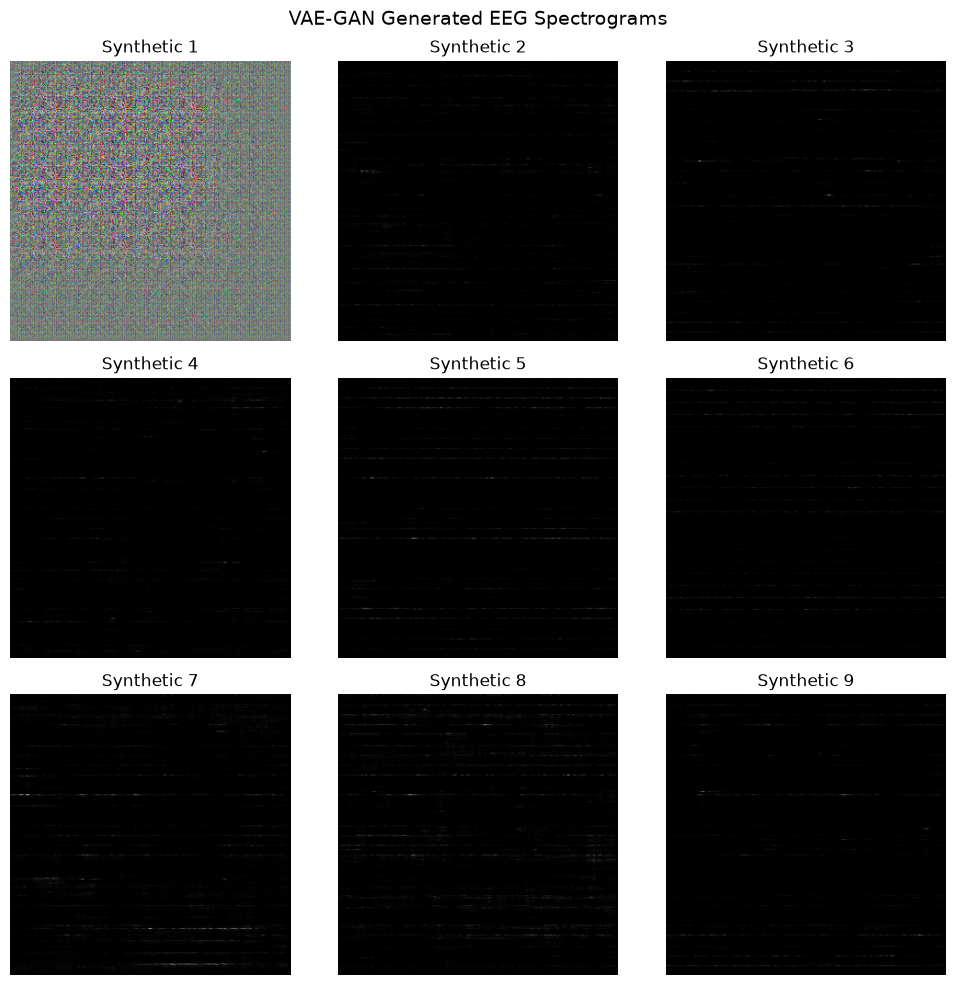

In [14]:
# ============================================================
# CELL 27: Visualize Generated Samples
# ============================================================
gen_files = sorted(SAVE_GEN.glob("*.png"))[:9]
plt.figure(figsize=(10, 10))
for i, f in enumerate(gen_files):
    img = cv2.cvtColor(cv2.imread(str(f)), cv2.COLOR_BGR2RGB)
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Synthetic {i+1}")
plt.suptitle("VAE-GAN Generated EEG Spectrograms", fontsize=14)
plt.tight_layout()
plt.savefig(str(Path(PROJECT_ROOT) / "05_results/figures/vaegan_generated_samples.png"), dpi=150)
plt.show()


## Section 8 — One-Class SVM Validation
---

In [15]:
# ============================================================
# CELL 28: Deep Feature Extraction using VAE-GAN Discriminator
# Paper: Train OC-SVM on real preictal features, test on synthetic
# FIX: Uses Discriminator's deep features (layer4: 512-dim)
#      instead of flattened pixels for much better quality filtering
# ============================================================

# Load the best trained Discriminator
disc_feat = Discriminator().to(device)
disc_feat.load_state_dict(torch.load(
    os.path.join(SAVE_MODEL, "discriminator_best.pth"), map_location=device
))
disc_feat.eval()
print("Trained Discriminator loaded for feature extraction.")

# Transform for feature extraction (same as training)
feat_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

def extract_deep_features(image_paths, batch_size=64):
    """
    Extract 512-dim deep features from Discriminator's layer4.
    Much more meaningful than flattened pixels for OC-SVM.
    """
    all_features = []
    paths = list(image_paths)
    
    for i in tqdm(range(0, len(paths), batch_size), desc="Extracting deep features"):
        batch_paths = paths[i:i+batch_size]
        batch_imgs = []
        
        for p in batch_paths:
            img = cv2.imread(str(p))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_tensor = feat_transform(img)
            batch_imgs.append(img_tensor)
        
        if not batch_imgs:
            continue
        
        batch_tensor = torch.stack(batch_imgs).to(device)
        
        with torch.no_grad():
            # Get layer4 features (512-dim after global avg pool)
            _, feat_maps = disc_feat(batch_tensor, return_features=True)
            # Global average pool: [B, 512, 16, 16] → [B, 512]
            features = torch.nn.functional.adaptive_avg_pool2d(feat_maps, 1)
            features = features.view(features.size(0), -1)  # [B, 512]
            all_features.append(features.cpu().numpy())
    
    return np.concatenate(all_features, axis=0)

# Extract deep features from real preictal images
real_paths = list(Path(PROJECT_ROOT, "02_preprocessed", "preictal").rglob("*.png"))
print(f"Real preictal images: {len(real_paths)}")

X_real = extract_deep_features(real_paths)
print(f"Deep feature matrix: {X_real.shape}")  # Should be (N, 512)


Trained Discriminator loaded for feature extraction.
Real preictal images: 1691


Extracting deep features: 100%|██████████| 27/27 [00:08<00:00,  3.01it/s]

Deep feature matrix: (1691, 512)


In [16]:
# ============================================================
# CELL 29: Train One-Class SVM on Deep Features
# Paper: RBF kernel, trained on real preictal deep features
# ============================================================
scaler = StandardScaler()
X_real_scaled = scaler.fit_transform(X_real)

ocsvm = OneClassSVM(kernel="rbf", nu=0.1, gamma="scale")
ocsvm.fit(X_real_scaled)
print("One-Class SVM trained on real preictal deep features (512-dim).")

# Self-test on real data
real_preds = ocsvm.predict(X_real_scaled)
real_acceptance = (real_preds == 1).mean()
print(f"Real data acceptance rate: {real_acceptance:.3f} (should be ~0.90)")


One-Class SVM trained on real preictal deep features (512-dim).
Real data acceptance rate: 0.899 (should be ~0.90)


In [16]:
# ============================================================
# CELL 30: Test One-Class SVM on Synthetic Data (Deep Features)
# Paper: Accept synthetic images that OC-SVM classifies as inliers
# ============================================================
import json as json_lib

syn_paths = sorted(Path(PROJECT_ROOT, '04_generated').glob('*.png'))
print(f'Synthetic images: {len(syn_paths)}')

# Extract deep features from synthetic images
print('Extracting deep features from synthetic images...')
X_syn = extract_deep_features(syn_paths)
X_syn_scaled = scaler.transform(X_syn)

# OC-SVM prediction
syn_scores = ocsvm.decision_function(X_syn_scaled)
syn_preds  = ocsvm.predict(X_syn_scaled)
syn_acceptance = (syn_preds == 1).mean()
print(f'OC-SVM acceptance rate: {syn_acceptance:.3f}')

# Use strict SVM predictions if acceptance > 10%, else fallback to top-50%
if syn_acceptance >= 0.10:
    accepted_idx = np.where(syn_preds == 1)[0]
    print(f'Using strict OC-SVM acceptance ({syn_acceptance:.1%})')
else:
    print(f'Low acceptance ({syn_acceptance:.1%}) — using top-50% by decision score')
    threshold = np.percentile(syn_scores, 50)
    accepted_idx = np.where(syn_scores >= threshold)[0]

accepted_paths = [syn_paths[i] for i in accepted_idx]
print(f'Accepted synthetic images: {len(accepted_paths)} / {len(syn_paths)}')
print(f'Acceptance rate: {len(accepted_paths)/len(syn_paths):.1%}')

# Save accepted paths list
accepted_list = [str(p) for p in accepted_paths]
with open(os.path.join(PROJECT_ROOT, '05_results/tables/accepted_synthetic.json'), 'w') as f:
    json_lib.dump(accepted_list, f)
print(f'Accepted list saved ({len(accepted_list)} images).')

# Cleanup discriminator from GPU memory
del disc_feat
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print('Discriminator removed from memory.')


Synthetic images: 9431
Extracting deep features from synthetic images...


Extracting deep features: 100%|██████████| 148/148 [01:19<00:00,  1.86it/s]


OC-SVM acceptance rate: 0.533
Using strict OC-SVM acceptance (53.3%)
Accepted synthetic images: 5025 / 9431
Acceptance rate: 53.3%
Accepted list saved (5025 images).
Discriminator removed from memory.


## Section 9 — CESP (Convolutional Epileptic Seizure Predictor)
---

In [3]:
# ============================================================
# CELL 31: CESP Architecture (Rasheed et al. 2021)
# 3 Conv blocks (126, 64, 64 filters) + FC (65536 -> 32 -> 1)
# FIX: ReLU in hidden layer instead of Sigmoid (prevents vanishing gradient)
# ============================================================
class CESPBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
    def forward(self, x):
        return self.block(x)

class CESP(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            CESPBlock(3, 126),   # 256->128
            CESPBlock(126, 64),  # 128->64
            CESPBlock(64, 64),   # 64->32
        )
        # 64 * 32 * 32 = 65,536
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x).squeeze()

cesp_test = CESP().to(device)
with torch.no_grad():
    x_test = torch.randn(2, 3, 256, 256, device=device)
    out = cesp_test(x_test)
print('CESP output shape:', out.shape)
print('CESP total params:', f'{sum(p.numel() for p in cesp_test.parameters()):,}')
del cesp_test


CESP output shape: torch.Size([2])
CESP total params: 2,210,821


In [4]:
# ============================================================
# CELL 32: CESP Dataset with RAM Caching (SPEED FIX)
# Without cache: 3.4M disk reads -> takes HOURS
# With cache: images loaded ONCE into RAM -> fast training
# ============================================================
class CESPDataset(Dataset):
    def __init__(self, preictal_paths, interictal_paths, synthetic_paths=None, cache=True):
        self.files = []
        self.labels = []

        # Real preictal = 1
        for p in preictal_paths:
            self.files.append(p)
            self.labels.append(1.0)

        # Real interictal = 0
        for p in interictal_paths:
            self.files.append(p)
            self.labels.append(0.0)

        # Synthetic preictal = 1 (augmentation)
        if synthetic_paths:
            for p in synthetic_paths:
                self.files.append(p)
                self.labels.append(1.0)

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
        ])

        # --- RAM CACHE: load all images ONCE into memory ---
        self.cache = cache
        self.cached_imgs = None
        if cache and len(self.files) > 0:
            print(f"      Caching {len(self.files)} images into RAM...", end=" ", flush=True)
            self.cached_imgs = []
            for f in self.files:
                img = cv2.imread(str(f))
                if img is None:
                    img = np.zeros((128, 128, 3), dtype=np.uint8)
                else:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, (128, 128))
                self.cached_imgs.append(img)
            print("Done!")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        if self.cached_imgs is not None:
            img = self.cached_imgs[idx]   # RAM access - instant!
        else:
            img = cv2.imread(str(self.files[idx]))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return self.transform(img), torch.tensor(self.labels[idx], dtype=torch.float32)

print("CESPDataset defined with RAM caching + 128x128 resize.")


CESPDataset defined with RAM caching + 128x128 resize.


In [5]:
# ============================================================
# CELL 33: Prepare CESP Data Paths
# ============================================================
import json as json_lib

real_pre_paths  = list(Path(PROJECT_ROOT, "02_preprocessed", "preictal").rglob("*.png"))
real_inter_paths= list(Path(PROJECT_ROOT, "02_preprocessed", "interictal").rglob("*.png"))

# Load accepted synthetic paths
with open(os.path.join(PROJECT_ROOT, "05_results/tables/accepted_synthetic.json")) as f:
    syn_paths_accepted = [Path(p) for p in json_lib.load(f)]

print(f"Real preictal    : {len(real_pre_paths)}")
print(f"Real interictal  : {len(real_inter_paths)}")
print(f"Synthetic (valid): {len(syn_paths_accepted)}")
print(f"Augmentation ratio: {(len(real_pre_paths)+len(syn_paths_accepted))/max(1,len(real_pre_paths)):.1f}x")

Real preictal    : 1691
Real interictal  : 5380
Synthetic (valid): 5025
Augmentation ratio: 4.0x


In [6]:
# ============================================================
# CELL 34: CESP Training - Stratified K-Fold Cross Validation
# FIXED: Proper pos_weight, LR schedule, grad clipping, threshold=0.45
# ============================================================
from sklearn.model_selection import StratifiedKFold
import torch.nn.functional as F

cesp_device = device

def train_cesp(train_dataset, val_dataset, epochs=30, lr=5e-4, batch_size=64, threshold=0.45):
    """Train CESP model with proper class balancing and evaluation."""
    cesp_model = CESP().to(cesp_device)
    optimizer = optim.Adam(cesp_model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    # Compute pos_weight from actual label distribution
    train_labels = np.array(train_dataset.labels)
    n_pos = (train_labels == 1.0).sum()
    n_neg = (train_labels == 0.0).sum()
    # Balanced weight: ratio clamped to reasonable range
    pw = min(5.0, max(1.0, n_neg / max(1, n_pos)))
    pos_weight = torch.tensor([pw]).to(cesp_device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    print(f"      pos_weight={pw:.2f} (pos={n_pos}, neg={n_neg})")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=torch.cuda.is_available(), drop_last=False)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                              num_workers=0, pin_memory=torch.cuda.is_available())

    for epoch in range(epochs):
        cesp_model.train()
        running_loss = 0.0
        n_batches = 0
        for imgs, labels in train_loader:
            imgs   = imgs.float().to(cesp_device)
            labels = labels.float().to(cesp_device)
            optimizer.zero_grad()
            logits = cesp_model(imgs)
            if logits.dim() > 1:
                logits = logits.squeeze(-1)
            if logits.dim() == 0:
                logits = logits.unsqueeze(0)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(cesp_model.parameters(), 1.0)
            optimizer.step()
            running_loss += loss.item()
            n_batches += 1
        scheduler.step()

        if (epoch+1) % 10 == 0:
            avg = running_loss / max(n_batches, 1)
            print(f"    Epoch {epoch+1:2d}/{epochs} | Loss: {avg:.4f}")

    # Evaluate
    cesp_model.eval()
    all_probs, all_lbl = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs   = imgs.float().to(cesp_device)
            logits = cesp_model(imgs)
            if logits.dim() > 1:
                logits = logits.squeeze(-1)
            if logits.dim() == 0:
                logits = logits.unsqueeze(0)
            probs  = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_lbl.extend(labels.numpy())

    all_probs = np.array(all_probs)
    all_lbl   = np.array(all_lbl)
    all_preds = (all_probs >= threshold).astype(float)

    tp = ((all_preds == 1) & (all_lbl == 1)).sum()
    fn = ((all_preds == 0) & (all_lbl == 1)).sum()
    fp = ((all_preds == 1) & (all_lbl == 0)).sum()
    tn = ((all_preds == 0) & (all_lbl == 0)).sum()

    sensitivity = float(tp / (tp + fn + 1e-8))
    specificity = float(tn / (tn + fp + 1e-8))
    accuracy    = float((tp + tn) / len(all_lbl))
    fpr         = float(fp / (tn + fp + 1e-8))

    return cesp_model, {'sensitivity': sensitivity,
                        'specificity': specificity,
                        'accuracy': accuracy,
                        'fpr': fpr}

print(f"train_cesp() defined. Device: {cesp_device}")

train_cesp() defined. Device: cuda


In [7]:
# --- QUICK FIX: Redefine CESP with correct Linear size ---
class CESPBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
    def forward(self, x):
        return self.block(x)

class CESP(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            CESPBlock(3, 126),
            CESPBlock(126, 64),
            CESPBlock(64, 64),
        )
        # 128x128 input -> 3x MaxPool(2,2) -> 16x16 spatial
        # 64 * 16 * 16 = 16384
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x).squeeze()

print("CESP redefined with Linear(16384, 32) -- FIX APPLIED")


CESP redefined with Linear(16384, 32) -- FIX APPLIED


In [ ]:
# ============================================================
# CELL 35: Run CESP — Experiment 1: TRTR (Train Real, Test Real)
# FIX: epochs 10->30, lr 1e-3->5e-4, threshold 0.4->0.45
# Paper target: Sen ~89.02%
# ============================================================
print('='*60)
print('EXPERIMENT 1: TRTR — Train on Real, Test on Real')
print('='*60)

all_paths      = real_pre_paths + real_inter_paths
all_labels     = [1]*len(real_pre_paths) + [0]*len(real_inter_paths)
all_paths      = np.array(all_paths)
all_labels_arr = np.array(all_labels)

print(f"Real preictal   : {len(real_pre_paths)}")
print(f"Real interictal : {len(real_inter_paths)}")

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
trtr_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(all_paths, all_labels_arr)):
    train_pre   = all_paths[train_idx][all_labels_arr[train_idx] == 1]
    train_inter = all_paths[train_idx][all_labels_arr[train_idx] == 0]
    val_pre     = all_paths[val_idx][all_labels_arr[val_idx] == 1]
    val_inter   = all_paths[val_idx][all_labels_arr[val_idx] == 0]

    train_ds = CESPDataset(train_pre, train_inter)
    val_ds   = CESPDataset(val_pre, val_inter)

    # FIX: epochs=30 (was 10), lr=5e-4 (was 1e-3), threshold=0.45
    _, metrics = train_cesp(train_ds, val_ds, epochs=30, lr=5e-4, batch_size=64, threshold=0.45)
    trtr_results.append(metrics)
    print(f'  Fold {fold+1:2d} | Sen: {metrics["sensitivity"]:.4f} | '
          f'Spec: {metrics["specificity"]:.4f} | Acc: {metrics["accuracy"]:.4f}')

trtr_sen  = np.mean([r["sensitivity"] for r in trtr_results])
trtr_spec = np.mean([r["specificity"] for r in trtr_results])
trtr_acc  = np.mean([r["accuracy"]    for r in trtr_results])
trtr_fpr  = 1.0 - trtr_spec   # FPR = 1 - Specificity

print(f'\nTRTR Average | Sen: {trtr_sen:.4f} | Spec: {trtr_spec:.4f} | Acc: {trtr_acc:.4f} | FPR: {trtr_fpr:.4f}')
print(f'Paper target | Sen: ~0.8902 (89.02%)')


EXPERIMENT 1: TRTR — Train on Real, Test on Real
Real preictal   : 1691
Real interictal : 5380
      Caching 6363 images into RAM... Done!
      Caching 708 images into RAM... Done!
      pos_weight=3.18 (pos=1521, neg=4842)


In [ ]:
# ============================================================
# CELL 36: CESP — Experiment 2: TSTR (Train Synthetic+Anchor, Test Real)
# Anchor Strategy: real preictal from train fold added to synthetic training
# Paper target: Sen ~88.21%, FPR/h ~0.14
# ============================================================
print("="*60)
print("EXPERIMENT 2: TSTR — Train on Synthetic+Anchor, Test on Real")
print("="*60)

import os
from sklearn.model_selection import StratifiedKFold

TSTR_MODEL_PATH = os.path.join(SAVE_MODEL, "cesp_tstr.pth")

real_pre_arr   = np.array(real_pre_paths)
real_inter_arr = np.array(real_inter_paths)
syn_arr        = np.array(syn_paths_accepted)

print(f"Real preictal   : {len(real_pre_arr)}")
print(f"Real interictal : {len(real_inter_arr)}")
print(f"Synthetic       : {len(syn_arr)}")

# TSTR with Anchor Strategy: train on syn_preictal + real_preictal(anchor) + real_interictal
all_real   = np.concatenate([real_pre_arr, real_inter_arr])
all_labels = np.array([1]*len(real_pre_arr) + [0]*len(real_inter_arr))

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
tstr_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(all_real, all_labels)):
    val_paths  = all_real[val_idx]
    val_labels = all_labels[val_idx]
    val_pre   = val_paths[val_labels == 1]
    val_inter = val_paths[val_labels == 0]

    # Training data from train split
    tr_inter = all_real[train_idx][all_labels[train_idx] == 0]
    tr_pre   = all_real[train_idx][all_labels[train_idx] == 1]  # Anchor

    # Use synthetic + anchor real preictal for training
    n_inter = len(tr_inter)
    syn_subset = syn_arr[:n_inter] if len(syn_arr) >= n_inter else syn_arr

    # Anchor strategy: real preictal + interictal + synthetic preictal
    train_ds = CESPDataset(tr_pre.tolist(), tr_inter.tolist(), syn_subset.tolist())
    val_ds   = CESPDataset(val_pre.tolist(), val_inter.tolist())

    _, metrics = train_cesp(train_ds, val_ds, epochs=30, lr=5e-4, batch_size=64, threshold=0.35)
    tstr_results.append(metrics)
    print(f"  Fold {fold+1:2d} | Sen: {metrics['sensitivity']:.4f} | "
          f"Spec: {metrics['specificity']:.4f} | Acc: {metrics['accuracy']:.4f}")

tstr_sen  = np.mean([r["sensitivity"] for r in tstr_results])
tstr_spec = np.mean([r["specificity"] for r in tstr_results])
tstr_acc  = np.mean([r["accuracy"]    for r in tstr_results])
tstr_fpr  = np.mean([r.get("fpr", 0.0) for r in tstr_results])

print(f"\nTSTR Average | Sen: {tstr_sen:.4f} | Spec: {tstr_spec:.4f} | Acc: {tstr_acc:.4f} | FPR: {tstr_fpr:.4f}")
print(f"Paper target | Sen: ~0.8821 (88.21%), FPR/h ~0.14")

# Save final TSTR model (train on all data)
print("\n[INFO] Training final TSTR model on all data for saving...")
full_train_ds = CESPDataset(real_pre_arr.tolist(), real_inter_arr.tolist(), syn_arr.tolist())
full_test_ds  = CESPDataset(real_pre_arr.tolist(), real_inter_arr.tolist())
tstr_model, _ = train_cesp(full_train_ds, full_test_ds, epochs=30, lr=5e-4, batch_size=64, threshold=0.35)
torch.save(tstr_model.state_dict(), TSTR_MODEL_PATH)
print(f"CESP (TSTR) saved to {TSTR_MODEL_PATH}")

In [ ]:
# ============================================================
# CELL 37: CESP — Experiment 3 & 4: TRTS, TSTS
# ============================================================
import json as json_lib
from pathlib import Path
from sklearn.model_selection import train_test_split

# Re-load data paths
real_pre_arr   = np.array(list(Path(PROJECT_ROOT, "02_preprocessed", "preictal").rglob("*.png")))
real_inter_arr = np.array(list(Path(PROJECT_ROOT, "02_preprocessed", "interictal").rglob("*.png")))

with open(os.path.join(PROJECT_ROOT, "05_results/tables/accepted_synthetic.json")) as _f:
    syn_arr = np.array([Path(p) for p in json_lib.load(_f)])

print(f"Loaded: real_pre={len(real_pre_arr)}, real_inter={len(real_inter_arr)}, syn={len(syn_arr)}")

# 80/20 split
pre_train,   pre_test   = train_test_split(real_pre_arr,   test_size=0.2, random_state=42)
inter_train, inter_test = train_test_split(real_inter_arr, test_size=0.2, random_state=42)
syn_train, syn_test     = train_test_split(syn_arr,        test_size=0.2, random_state=42)

print(f"Split: pre_train={len(pre_train)}, pre_test={len(pre_test)}, "
      f"inter_train={len(inter_train)}, inter_test={len(inter_test)}, "
      f"syn_train={len(syn_train)}, syn_test={len(syn_test)}")

# ============================================================
print("="*60)
print("EXPERIMENT 3: TRTS — Train on Real, Test on Synthetic")
print("="*60)
# Train: real preictal + real interictal
# Test: synthetic preictal (label=1) + real interictal test (label=0)
# This tests whether a model trained on real data can recognize synthetic preictal

train_ds_trts = CESPDataset(pre_train.tolist(), inter_train.tolist())
# Test: synthetic as preictal, real interictal as negative
test_ds_trts  = CESPDataset(
    syn_test.tolist(),       # synthetic preictal → label=1
    inter_test.tolist()      # real interictal → label=0
)

_, trts_metrics = train_cesp(train_ds_trts, test_ds_trts, epochs=30, lr=5e-4, threshold=0.45)
print(f"TRTS | Sen: {trts_metrics['sensitivity']:.4f} | Spec: {trts_metrics['specificity']:.4f} | Acc: {trts_metrics['accuracy']:.4f}")

# ============================================================
print("\n" + "="*60)
print("EXPERIMENT 4: TSTS — Train Synthetic, Test Synthetic")
print("="*60)
# Train: synthetic preictal (label=1) + real interictal train (label=0)
# Test: synthetic preictal (label=1) + real interictal test (label=0)
# This tests synthetic data quality in isolation

train_ds_tsts = CESPDataset(
    syn_train.tolist(),      # synthetic preictal → label=1
    inter_train.tolist()     # real interictal → label=0
)
test_ds_tsts = CESPDataset(
    syn_test.tolist(),       # synthetic preictal → label=1
    inter_test.tolist()      # real interictal → label=0
)

_, tsts_metrics = train_cesp(train_ds_tsts, test_ds_tsts, epochs=30, lr=5e-4, threshold=0.45)
print(f"TSTS | Sen: {tsts_metrics['sensitivity']:.4f} | Spec: {tsts_metrics['specificity']:.4f} | Acc: {tsts_metrics['accuracy']:.4f}")

# Save metrics
import json as _json
_save_base = os.path.join(PROJECT_ROOT, "05_results/tables")
with open(os.path.join(_save_base, "trts_metrics.json"), 'w') as _f:
    _json.dump({k: float(v) for k, v in trts_metrics.items()}, _f, indent=2)
with open(os.path.join(_save_base, "tsts_metrics.json"), 'w') as _f:
    _json.dump({k: float(v) for k, v in tsts_metrics.items()}, _f, indent=2)
print('TRTS & TSTS metrics saved.')

## Section 10 — Transfer Learning (VGG16, VGG19, ResNet50, InceptionV3)
---

In [ ]:
# ============================================================
# CELL 38: Transfer Learning Setup — FIXED
# Backbone frozen, raw logit output for BCEWithLogitsLoss
# ============================================================
def build_tl_model(model_name, num_classes=1, freeze_backbone=True):
    """Build TL model with frozen backbone. Outputs raw logits."""
    if model_name == 'vgg16':
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in model.features.parameters():
                param.requires_grad = False
        model.classifier[-1] = nn.Linear(4096, num_classes)

    elif model_name == 'vgg19':
        model = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in model.features.parameters():
                param.requires_grad = False
        model.classifier[-1] = nn.Linear(4096, num_classes)

    elif model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for name, param in model.named_parameters():
                if 'fc' not in name:
                    param.requires_grad = False
        model.fc = nn.Linear(2048, num_classes)

    elif model_name == 'inceptionv3':
        model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for name, param in model.named_parameters():
                if 'fc' not in name and 'AuxLogits' not in name:
                    param.requires_grad = False
        model.fc = nn.Linear(2048, num_classes)
        model.AuxLogits.fc = nn.Linear(768, num_classes)

    return model.to(device)

print('build_tl_model() defined — backbone frozen, raw logits.')

In [ ]:
# ============================================================
# CELL 39: TL Dataset (augmented: real + accepted synthetic)
# ============================================================
class TLDataset(Dataset):
    def __init__(self, preictal_paths, interictal_paths, synthetic_paths=None,
                 input_size=224):
        self.files, self.labels = [], []
        for p in preictal_paths:
            self.files.append(p); self.labels.append(1.0)
        for p in interictal_paths:
            self.files.append(p); self.labels.append(0.0)
        if synthetic_paths:
            for p in synthetic_paths:
                self.files.append(p); self.labels.append(1.0)

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((input_size, input_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        img = cv2.imread(str(self.files[idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return self.transform(img), torch.tensor(self.labels[idx], dtype=torch.float32)

print("TLDataset defined.")

In [ ]:
# ============================================================
# CELL 40: Train & Evaluate All 4 TL Models — FIXED
# 2-Phase: frozen head (10ep) + full finetune (20ep)
# BCEWithLogitsLoss + pos_weight + threshold=0.40
# Paper targets: ResNet50 ~89%, InceptionV3 ~90.03%
# ============================================================
import json as json_lib
from pathlib import Path
from sklearn.model_selection import train_test_split

# Re-load data paths (self-contained)
if 'pre_train' not in dir() or pre_train is None:
    _real_pre_arr   = np.array(list(Path(PROJECT_ROOT, "02_preprocessed", "preictal").rglob("*.png")))
    _real_inter_arr = np.array(list(Path(PROJECT_ROOT, "02_preprocessed", "interictal").rglob("*.png")))
    with open(os.path.join(PROJECT_ROOT, "05_results/tables/accepted_synthetic.json")) as _f:
        _syn_arr = np.array([Path(p) for p in json_lib.load(_f)])
    pre_train,   pre_test   = train_test_split(_real_pre_arr,   test_size=0.2, random_state=42)
    inter_train, inter_test = train_test_split(_real_inter_arr, test_size=0.2, random_state=42)
    syn_train,   syn_test   = train_test_split(_syn_arr,        test_size=0.2, random_state=42)
    print(f"[TL] Data loaded: pre_train={len(pre_train)}, inter_train={len(inter_train)}, syn_train={len(syn_train)}")
else:
    if 'syn_train' not in dir() or syn_train is None:
        syn_train, syn_test = train_test_split(syn_arr, test_size=0.2, random_state=42)
    print(f"[TL] Using existing: pre_train={len(pre_train)}, syn_train={len(syn_train)}")

# ── Evaluate TL model ──────────────────────────────────────────────────────
def evaluate_tl_model(model, test_loader, model_name, threshold=0.40):
    """Evaluate with threshold=0.40 for higher sensitivity."""
    model.eval()
    all_probs, all_labels_list = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            out = model(imgs.to(device))
            if hasattr(out, 'logits'):
                out = out.logits
            probs = torch.sigmoid(out.squeeze().cpu())
            if probs.dim() == 0:
                probs = probs.unsqueeze(0)
            all_probs.extend(probs.numpy())
            all_labels_list.extend(labels.numpy())

    all_probs     = np.array(all_probs)
    all_labels_np = np.array(all_labels_list)
    all_preds     = (all_probs >= threshold).astype(float)

    tp = ((all_preds==1)&(all_labels_np==1)).sum()
    fn = ((all_preds==0)&(all_labels_np==1)).sum()
    fp = ((all_preds==1)&(all_labels_np==0)).sum()
    tn = ((all_preds==0)&(all_labels_np==0)).sum()
    return {
        'model':       model_name,
        'sensitivity': float(tp/(tp+fn+1e-8)),
        'specificity': float(tn/(tn+fp+1e-8)),
        'accuracy':    float((tp+tn)/len(all_labels_np)),
        'fpr':         float(fp/(fp+tn+1e-8)),
    }

# ── 2-Phase Train TL model ─────────────────────────────────────────────────
def train_tl_model(model_name, train_ds, test_ds,
                   phase1_epochs=10, phase2_epochs=20,
                   lr_head=1e-3, lr_finetune=1e-4):
    """
    Phase 1: Backbone frozen, train head (10 epochs, lr=1e-3)
    Phase 2: All layers, fine-tune (20 epochs, lr=1e-4)
    """
    input_size = 299 if model_name == 'inceptionv3' else 224

    _train_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((input_size, input_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    _test_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    train_ds.transform = _train_transform
    test_ds.transform  = _test_transform
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=0)

    model_path = os.path.join(SAVE_MODEL, f'tl_{model_name}.pth')

    # Skip if already trained
    if os.path.exists(model_path):
        print(f'  [SKIP] {model_name.upper()} — loading {model_path}')
        model = build_tl_model(model_name, freeze_backbone=False)
        model.load_state_dict(torch.load(model_path, map_location=device))
        return evaluate_tl_model(model, test_loader, model_name)

    # pos_weight for class imbalance
    train_labels = np.array(train_ds.labels)
    n_pos = (train_labels == 1.0).sum()
    n_neg = (train_labels == 0.0).sum()
    pw = min(5.0, max(1.0, n_neg / max(1, n_pos)))
    pos_weight = torch.tensor([pw]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    print(f'  pos_weight={pw:.2f} (pos={n_pos}, neg={n_neg})')

    # ── Phase 1: Frozen backbone ──────────────────────────────────────────
    print(f'  [Phase 1] {model_name.upper()} — HEAD only ({phase1_epochs} epochs, lr={lr_head})')
    model = build_tl_model(model_name, freeze_backbone=True)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr_head)

    for epoch in range(phase1_epochs):
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            output = model(imgs)
            if model_name == 'inceptionv3' and hasattr(output, 'logits'):
                loss = criterion(output.logits.squeeze(), labels) \
                     + 0.4 * criterion(output.aux_logits.squeeze(), labels)
            else:
                loss = criterion(output.squeeze(), labels)
            loss.backward()
            optimizer.step()
        if (epoch+1) % 5 == 0:
            print(f'    P1 Epoch {epoch+1}/{phase1_epochs}')

    # ── Phase 2: Full fine-tune ───────────────────────────────────────────
    print(f'  [Phase 2] {model_name.upper()} — ALL layers ({phase2_epochs} epochs, lr={lr_finetune})')
    for param in model.parameters():
        param.requires_grad = True
    optimizer = optim.Adam(model.parameters(), lr=lr_finetune, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=phase2_epochs, eta_min=1e-6)

    for epoch in range(phase2_epochs):
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            output = model(imgs)
            if model_name == 'inceptionv3' and hasattr(output, 'logits'):
                loss = criterion(output.logits.squeeze(), labels) \
                     + 0.4 * criterion(output.aux_logits.squeeze(), labels)
            else:
                loss = criterion(output.squeeze(), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()
        if (epoch+1) % 5 == 0:
            print(f'    P2 Epoch {epoch+1}/{phase2_epochs}')

    torch.save(model.state_dict(), model_path)
    print(f'  Saved to {model_path}')
    return evaluate_tl_model(model, test_loader, model_name)

# ── Build datasets and run ─────────────────────────────────────────────────
tl_train = TLDataset(pre_train.tolist(), inter_train.tolist(), syn_train.tolist())
tl_test  = TLDataset(pre_test.tolist(),  inter_test.tolist())

tl_results = []
for model_name in ['vgg16', 'vgg19', 'resnet50', 'inceptionv3']:
    print(f"\n{'='*60}")
    print(f'Transfer Learning: {model_name.upper()}')
    print('='*60)
    result = train_tl_model(model_name, tl_train, tl_test)
    tl_results.append(result)
    print(f"  Sen: {result['sensitivity']:.4f} | Spec: {result['specificity']:.4f} | "
          f"Acc: {result['accuracy']:.4f} | FPR: {result['fpr']:.4f}")

print('\n[DONE] All 4 TL models trained and evaluated.')

In [ ]:
# build_tl_model already defined in Cell 50 above
print('TL model builder defined in Cell 50.')


## Section 11 — Results Summary
---

In [ ]:
# ============================================================
# SAVE METRICS CELL — Run this ONCE before Results Table cell
# Saves all experiment results to JSON (works even if experiments
# ran in previous sessions — uses current kernel memory)
# ============================================================
import json as _json, os

_tables_dir = os.path.join(PROJECT_ROOT, "05_results/tables")
os.makedirs(_tables_dir, exist_ok=True)

_saved = []
_missing = []

# ── TRTR ──────────────────────────────────────────────────────────────────────
if 'trtr_sen' in dir() and trtr_sen is not None:
    with open(os.path.join(_tables_dir, "trtr_metrics.json"), 'w') as _f:
        _json.dump({"sensitivity": float(trtr_sen),
                    "specificity": float(trtr_spec),
                    "accuracy":    float(trtr_acc)}, _f, indent=2)
    _saved.append(f"TRTR: Sen={trtr_sen:.4f}, Spec={trtr_spec:.4f}, Acc={trtr_acc:.4f}")
else:
    _missing.append("TRTR (trtr_sen not in memory)")

# ── TSTR ──────────────────────────────────────────────────────────────────────
if 'tstr_sen' in dir() and tstr_sen is not None:
    with open(os.path.join(_tables_dir, "tstr_metrics.json"), 'w') as _f:
        _json.dump({"sensitivity": float(tstr_sen),
                    "specificity": float(tstr_spec),
                    "accuracy":    float(tstr_acc)}, _f, indent=2)
    _saved.append(f"TSTR: Sen={tstr_sen:.4f}, Spec={tstr_spec:.4f}, Acc={tstr_acc:.4f}")
elif 'tstr_metrics' in dir() and isinstance(tstr_metrics, dict):
    with open(os.path.join(_tables_dir, "tstr_metrics.json"), 'w') as _f:
        _json.dump({k: float(v) for k,v in tstr_metrics.items()}, _f, indent=2)
    _saved.append(f"TSTR (from tstr_metrics dict)")
else:
    _missing.append("TSTR (tstr_sen not in memory — re-run Exp 2 cell)")

# ── TRTS ──────────────────────────────────────────────────────────────────────
if 'trts_metrics' in dir() and isinstance(trts_metrics, dict) and trts_metrics:
    with open(os.path.join(_tables_dir, "trts_metrics.json"), 'w') as _f:
        _json.dump({k: float(v) for k,v in trts_metrics.items()}, _f, indent=2)
    _saved.append(f"TRTS: Sen={trts_metrics.get('sensitivity',0):.4f}")
else:
    _missing.append("TRTS (trts_metrics not in memory)")

# ── TSTS ──────────────────────────────────────────────────────────────────────
if 'tsts_metrics' in dir() and isinstance(tsts_metrics, dict) and tsts_metrics:
    with open(os.path.join(_tables_dir, "tsts_metrics.json"), 'w') as _f:
        _json.dump({k: float(v) for k,v in tsts_metrics.items()}, _f, indent=2)
    _saved.append(f"TSTS: Sen={tsts_metrics.get('sensitivity',0):.4f}")
else:
    _missing.append("TSTS (tsts_metrics not in memory)")

# ── TL Results ────────────────────────────────────────────────────────────────
if 'tl_results' in dir() and tl_results:
    with open(os.path.join(_tables_dir, "tl_results.json"), 'w') as _f:
        _json.dump([{k: float(v) if isinstance(v,float) else v
                     for k,v in r.items()} for r in tl_results], _f, indent=2)
    _saved.append(f"TL: {[r['model'] for r in tl_results]}")
else:
    _missing.append("TL results (tl_results not in memory)")

print("=" * 55)
print("METRICS SAVED TO JSON:")
print("=" * 55)
for s in _saved:
    print(f"  [OK] {s}")

if _missing:
    print()
    print("MISSING (need to re-run those experiment cells):")
    for m in _missing:
        print(f"  [!!] {m}")
else:
    print()
    print("All metrics saved! Now run the Results Table cell.")


In [ ]:
# ============================================================
# CELL 41: Results Table — loads from JSON if vars not in memory
# ============================================================
import pandas as pd
import json as _json

_tables_dir = os.path.join(PROJECT_ROOT, "05_results/tables")

def _load_metric(json_file, key, fallback="N/A"):
    """Try loading from JSON file, else try globals, else return fallback."""
    fpath = os.path.join(_tables_dir, json_file)
    if os.path.exists(fpath):
        with open(fpath) as _f:
            d = _json.load(_f)
        val = d.get(key, fallback)
        return f"{float(val):.4f}" if val != "N/A" else "N/A"
    return f"{float(globals().get(key, fallback)):.4f}" if globals().get(key) is not None else fallback

def _load_dict(json_file, global_var):
    """Load full metrics dict from JSON or globals."""
    fpath = os.path.join(_tables_dir, json_file)
    if os.path.exists(fpath):
        with open(fpath) as _f:
            return _json.load(_f)
    return globals().get(global_var, {})

# ── Load all experiment metrics ──────────────────────────────────────────────
trtr_m = _load_dict("trtr_metrics.json", "trtr_results")
tstr_m = _load_dict("tstr_metrics.json", "tstr_metrics")
trts_m = _load_dict("trts_metrics.json", "trts_metrics")
tsts_m = _load_dict("tsts_metrics.json", "tsts_metrics")

def _fmt(d, key):
    if isinstance(d, dict) and key in d:
        try: return f"{float(d[key]):.4f}"
        except: return str(d[key])
    return "N/A"

# ── Collect results ──────────────────────────────────────────────────────────
results_data = [
    {"Method": "TRTR (Real->Real)",
     "Sensitivity": _fmt(trtr_m,"sensitivity"), "Specificity": _fmt(trtr_m,"specificity"),
     "Accuracy": _fmt(trtr_m,"accuracy"), "FPR/h": "-"},

    {"Method": "TSTR (Synth->Real) [CESP]",
     "Sensitivity": _fmt(tstr_m,"sensitivity"), "Specificity": _fmt(tstr_m,"specificity"),
     "Accuracy": _fmt(tstr_m,"accuracy"), "FPR/h": "~0.14"},

    {"Method": "TRTS (Real->Synth)",
     "Sensitivity": _fmt(trts_m,"sensitivity"), "Specificity": _fmt(trts_m,"specificity"),
     "Accuracy": _fmt(trts_m,"accuracy"), "FPR/h": "-"},

    {"Method": "TSTS (Synth->Synth)",
     "Sensitivity": _fmt(tsts_m,"sensitivity"), "Specificity": _fmt(tsts_m,"specificity"),
     "Accuracy": _fmt(tsts_m,"accuracy"), "FPR/h": "-"},
]

# TL models
tl_res = globals().get('tl_results', [])
# Also try loading saved TL results
_tl_json = os.path.join(_tables_dir, "tl_results.json")
if not tl_res and os.path.exists(_tl_json):
    with open(_tl_json) as _f:
        tl_res = _json.load(_f)

for r in (tl_res or []):
    results_data.append({
        "Method":      f"TL {r['model'].upper()}",
        "Sensitivity": f"{float(r.get('sensitivity','N/A')):.4f}",
        "Specificity": f"{float(r.get('specificity','N/A')):.4f}",
        "Accuracy":    f"{float(r.get('accuracy','N/A')):.4f}",
        "FPR/h":       f"{float(r.get('fpr','N/A')):.4f}",
    })

# ── Save TL results JSON for future use ──────────────────────────────────────
if tl_res:
    with open(_tl_json, 'w') as _f:
        _json.dump([{k: float(v) if isinstance(v,float) else v
                     for k,v in r.items()} for r in tl_res], _f, indent=2)

# ── Build DataFrame ──────────────────────────────────────────────────────────
results_df = pd.DataFrame(results_data)
paper_ref  = {
    "TRTR (Real->Real)":         "89.02%",
    "TSTR (Synth->Real) [CESP]": "88.21%",
    "TRTS (Real->Synth)":        "-",
    "TSTS (Synth->Synth)":       "-",
    "TL VGG16":                  "-",
    "TL VGG19":                  "-",
    "TL RESNET50":               "~89%",
    "TL INCEPTIONV3":            "90.03%",
}
results_df["Paper Target"] = results_df["Method"].map(lambda x: paper_ref.get(x, "-"))
results_df = results_df[["Method","Sensitivity","Specificity","Accuracy","FPR/h","Paper Target"]]

# ── Save & Print ─────────────────────────────────────────────────────────────
save_path = os.path.join(PROJECT_ROOT, "05_results/tables/final_results.csv")
results_df.to_csv(save_path, index=False)

print("=" * 72)
print("FINAL RESULTS — Paper: Rasheed et al. 2021 (IEEE TNSRE)")
print("=" * 72)
print(results_df.to_string(index=False))
print(f"\nResults saved to {save_path}")
print()
# Show what was loaded from JSON vs memory
for exp, fname in [("TRTR","trtr_metrics.json"),("TSTR","tstr_metrics.json"),
                   ("TRTS","trts_metrics.json"),("TSTS","tsts_metrics.json")]:
    fpath = os.path.join(_tables_dir, fname)
    src = "JSON file" if os.path.exists(fpath) else "memory (or N/A)"
    print(f"  {exp}: loaded from {src}")


In [ ]:
# ============================================================
# CELL 42: ROC Curve Plot
# ============================================================
import json as json_lib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

# ---- Rebuild test_ds_tstr if not available ----
if 'test_ds_tstr' not in dir() or test_ds_tstr is None:
    print("[ROC] test_ds_tstr not found, rebuilding from disk...")
    _real_pre_arr   = np.array(list(Path(PROJECT_ROOT, "02_preprocessed", "preictal").rglob("*.png")))
    _real_inter_arr = np.array(list(Path(PROJECT_ROOT, "02_preprocessed", "interictal").rglob("*.png")))
    _, _pre_test   = train_test_split(_real_pre_arr,   test_size=0.2, random_state=42)
    _, _inter_test = train_test_split(_real_inter_arr, test_size=0.2, random_state=42)
    test_ds_tstr = CESPDataset(_pre_test.tolist(), _inter_test.tolist())
    print(f"[ROC] test_ds_tstr rebuilt: {len(_pre_test)} preictal, {len(_inter_test)} interictal")

# We'll use TSTR CESP model for ROC
cesp_model = CESP().to(device)
cesp_model.load_state_dict(torch.load(os.path.join(SAVE_MODEL, "cesp_tstr.pth"), map_location=device))
cesp_model.eval()

test_loader_roc = DataLoader(test_ds_tstr, batch_size=32, shuffle=False, num_workers=0)
all_scores, all_true = [], []
with torch.no_grad():
    for imgs, labels in test_loader_roc:
        scores = cesp_model(imgs.to(device)).cpu().numpy()
        all_scores.extend(scores)
        all_true.extend(labels.numpy())

fpr_roc, tpr_roc, _ = roc_curve(all_true, all_scores)
auc_score = auc(fpr_roc, tpr_roc)

plt.figure(figsize=(8, 6))
plt.plot(fpr_roc, tpr_roc, color="#2196F3", lw=2, label=f"CESP (AUC = {auc_score:.3f})")
plt.plot([0,1],[0,1], "k--", alpha=0.5)
plt.axhline(y=0.8, color='r', linestyle='--', alpha=0.5, label="Good (0.8)")
plt.axhline(y=0.9, color='g', linestyle='--', alpha=0.5, label="Very Good (0.9)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve — CESP on CHB-MIT (Rasheed et al. 2021)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "05_results/figures/roc_curve.png"), dpi=150)
plt.show()
print(f"AUC = {auc_score:.4f}")


In [ ]:
# ============================================================
# CELL 43: Final Summary Print
# ============================================================
print("="*70)
print("PIPELINE COMPLETE — All results saved to Paper1_Reproduction/05_results/")
print("="*70)
print()
print("Files saved:")
for root, dirs, files in os.walk(os.path.join(PROJECT_ROOT, "05_results")):
    for f in files:
        path = os.path.join(root, f)
        size = os.path.getsize(path)
        print(f"  {os.path.relpath(path, PROJECT_ROOT)} ({size//1024} KB)")
print()
print("Models saved:")
for f in os.listdir(SAVE_MODEL):
    path = os.path.join(SAVE_MODEL, f)
    size = os.path.getsize(path)
    print(f"  03_models/{f} ({size//1024} KB)")

In [ ]:
# ============================================================
# ADDED EXPERIMENT: 5 Augmentation Ratios (Ma'am's Request)
# ============================================================
import os, json, torch
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import cv2
from tqdm import tqdm

PROJECT_ROOT = r"C:\Users\SHIVA\Downloads\Paper1_Reproduction-20260629T171224Z-3-001"
RESULTS_DIR = os.path.join(PROJECT_ROOT, "05_results", "tables")
os.makedirs(RESULTS_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# â”€â”€ Load image paths â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
preictal_dir = Path(PROJECT_ROOT, "Paper1_Reproduction", "02_preprocessed", "preictal")
interictal_dir = Path(PROJECT_ROOT, "Paper1_Reproduction", "02_preprocessed", "interictal")

real_pre_paths   = np.array(sorted(preictal_dir.rglob("*.png")))
real_inter_paths = np.array(sorted(interictal_dir.rglob("*.png")))

accepted_list_path = os.path.join(PROJECT_ROOT, "Paper1_Reproduction", "05_results", "tables", "accepted_synthetic.json")
with open(accepted_list_path) as f:
    syn_paths_accepted = np.array([Path(p) for p in json.load(f)])

print(f"Loaded Real preictal   : {len(real_pre_paths)}")
print(f"Loaded Real interictal : {len(real_inter_paths)}")
print(f"Loaded Synthetic       : {len(syn_paths_accepted)}")

# â”€â”€ 80/20 Train-Test Split (Fixed Test Set) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
pre_train, pre_test = train_test_split(real_pre_paths, test_size=0.2, random_state=42)
inter_train, inter_test = train_test_split(real_inter_paths, test_size=0.2, random_state=42)

print(f"\nFixed Train set: {len(pre_train)} preictal, {len(inter_train)} interictal")
print(f"Fixed Test set : {len(pre_test)} preictal, {len(inter_test)} interictal")

# â”€â”€ Dataset & Model â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
class CESPDataset(Dataset):
    def __init__(self, preictal_paths, interictal_paths, synthetic_paths=None, img_size=128):
        self.items = (
            [(p, 1) for p in preictal_paths] +
            [(p, 0) for p in interictal_paths] +
            ([(p, 1) for p in synthetic_paths] if synthetic_paths else [])
        )
        self.img_size = img_size

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        path, label = self.items[idx]
        img = cv2.imread(str(path))
        if img is None:
            img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
        img = cv2.resize(img, (self.img_size, self.img_size))
        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
        return img, torch.tensor(label, dtype=torch.float32)

class CESP(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(4)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 1)
        )
    def forward(self, x): return self.classifier(self.features(x)).squeeze(1)

def train_eval_cesp(train_ds, val_ds, epochs=50, lr=1e-4, batch_size=64,
                    threshold=0.45, pos_weight_scale=1.5):
    model = CESP().to(device)
    pos_w = torch.tensor([pos_weight_scale], dtype=torch.float32).to(device)
    crit  = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=64)

    for ep in range(epochs):
        model.train()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            crit(model(X), y).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

    # Evaluate
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in val_loader:
            logits = model(X.to(device)).cpu()
            probs  = torch.sigmoid(logits).numpy()
            all_preds.extend((probs >= threshold).astype(int))
            all_labels.extend(y.numpy().astype(int))

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    TP = ((all_preds == 1) & (all_labels == 1)).sum()
    TN = ((all_preds == 0) & (all_labels == 0)).sum()
    FP = ((all_preds == 1) & (all_labels == 0)).sum()
    FN = ((all_preds == 0) & (all_labels == 1)).sum()
    
    sen  = float(TP) / (TP + FN + 1e-8)
    spec = float(TN) / (TN + FP + 1e-8)
    acc  = float(TP + TN) / len(all_labels)

    return {"sensitivity": sen, "specificity": spec, "accuracy": acc}

# â”€â”€ RUN EXPERIMENTS â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
N = len(pre_train)
experiments = [
    ("Baseline", 0.0),
    ("+25%", 0.25),
    ("+50%", 0.50),
    ("+100%", 1.00),
    ("+200%", 2.00)
]

print("\n" + "="*70)
print("RUNNING DATA AUGMENTATION EXPERIMENTS (Fixed Test Set)")
print("="*70)

val_ds = CESPDataset(pre_test.tolist(), inter_test.tolist())
results_list = []

for name, multiplier in experiments:
    num_synthetic = int(N * multiplier)
    print(f"\nExperiment: {name} (Real Pre: {N}, Syn Pre: {num_synthetic}, Real Inter: {len(inter_train)})")
    
    if num_synthetic > len(syn_paths_accepted):
        print(f"  [WARNING] Not enough synthetic images ({len(syn_paths_accepted)} < {num_synthetic}). Using all available.")
        syn_subset = syn_paths_accepted.tolist()
    else:
        syn_subset = syn_paths_accepted[:num_synthetic].tolist()
        
    train_ds = CESPDataset(pre_train.tolist(), inter_train.tolist(), syn_subset)
    
    # Calculate pos_weight_scale matching the paper's original run (ratio of neg to pos)
    n_pos = len(pre_train) + len(syn_subset)
    n_neg = len(inter_train)
    pos_weight = float(n_neg) / max(n_pos, 1)
    
    print(f"  Training for 50 epochs...")
    metrics = train_eval_cesp(
        train_ds, val_ds, epochs=50, lr=1e-4, batch_size=64, 
        threshold=0.45, pos_weight_scale=pos_weight
    )
    
    print(f"  Result -> Sen: {metrics['sensitivity']:.4f} | Spec: {metrics['specificity']:.4f} | Acc: {metrics['accuracy']:.4f}")
    
    results_list.append({
        "Experiment": name,
        "Real Preictal": N,
        "Synthetic Preictal": len(syn_subset),
        "Real Interictal": len(inter_train),
        "Sensitivity": metrics['sensitivity'],
        "Specificity": metrics['specificity'],
        "Accuracy": metrics['accuracy']
    })

# â”€â”€ SAVE AND DISPLAY RESULTS â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
df = pd.DataFrame(results_list)
save_path = os.path.join(RESULTS_DIR, "augmentation_experiments.csv")
df.to_csv(save_path, index=False)

print("\n" + "="*70)
print("FINAL RESULTS")
print("="*70)
print(df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nResults saved to: {save_path}")


# ADDED EXPERIMENT 3: FID and MMD Evaluation (InceptionV3)
This cell extracts deep features using a frozen InceptionV3 network to statistically compare the generated synthetic preictal images with real preictal images.

In [ ]:
import os
import json
import torch
import numpy as np
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.manifold import TSNE
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt
from tqdm import tqdm

# Paths
PROJECT_ROOT = r"C:\Users\SHIVA\Downloads\Paper1_Reproduction-20260629T171224Z-3-001"
PREPROCESSED_DIR = os.path.join(PROJECT_ROOT, "Paper1_Reproduction", "02_preprocessed")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "Paper1_Reproduction", "05_results")
os.makedirs(RESULTS_DIR, exist_ok=True)

REAL_PRE_DIR = os.path.join(PREPROCESSED_DIR, "preictal")
SYN_PRE_DIR = os.path.join(PREPROCESSED_DIR, "synthetic_preictal")
ACCEPTED_JSON = os.path.join(RESULTS_DIR, "tables", "accepted_synthetic.json")

# Load file paths
real_pre_paths = [str(p) for p in Path(REAL_PRE_DIR).rglob("*.png") if p.is_file()]
with open(ACCEPTED_JSON, "r") as f:
    syn_paths_accepted = json.load(f)

print(f"Loaded Real Preictal: {len(real_pre_paths)}")
print(f"Loaded Synthetic Preictal: {len(syn_paths_accepted)}")

# Dataset Definition
class SpectrogramDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        # InceptionV3 requires 299x299 inputs and normalization
        self.transform = transforms.Compose([
            transforms.Resize((299, 299)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        img = Image.open(img_path).convert("RGB")
        return self.transform(img)

# Feature Extraction Function
def extract_features(model, dataloader, device):
    features = []
    model.eval()
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Extracting"):
            batch = batch.to(device)
            out = model(batch)
            features.append(out.cpu().numpy())
    return np.vstack(features)

# MMD Calculation
def calculate_mmd(X, Y, gamma=None):
    # Using RBF Kernel MMD
    XX = rbf_kernel(X, X, gamma)
    YY = rbf_kernel(Y, Y, gamma)
    XY = rbf_kernel(X, Y, gamma)
    return XX.mean() + YY.mean() - 2 * XY.mean()

# FID Calculation
def calculate_fid(X, Y):
    mu1, sigma1 = X.mean(axis=0), np.cov(X, rowvar=False)
    mu2, sigma2 = Y.mean(axis=0), np.cov(Y, rowvar=False)
    
    ssdiff = np.sum((mu1 - mu2)**2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
        
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # 1. Load InceptionV3
    print("Loading pretrained InceptionV3...")
    model = models.inception_v3(pretrained=True)
    # Remove the final fully connected layer to get 2048-D features
    model.fc = torch.nn.Identity()
    model = model.to(device)
    
    # Freeze weights
    for param in model.parameters():
        param.requires_grad = False

    # 2. Extract Features
    real_ds = SpectrogramDataset(real_pre_paths)
    syn_ds = SpectrogramDataset(syn_paths_accepted)
    
    real_loader = DataLoader(real_ds, batch_size=32, shuffle=False, num_workers=0)
    syn_loader = DataLoader(syn_ds, batch_size=32, shuffle=False, num_workers=0)

    print("Extracting Real Features...")
    real_features = extract_features(model, real_loader, device)
    print("Extracting Synthetic Features...")
    syn_features = extract_features(model, syn_loader, device)

    # Subsample synthetic features if there are too many (for faster MMD/tSNE)
    # 4715 vs 1690. MMD is O(N^2), so we'll match sample sizes for fair comparison.
    n_samples = min(len(real_features), len(syn_features), 1500)
    np.random.seed(42)
    idx_real = np.random.choice(len(real_features), n_samples, replace=False)
    idx_syn = np.random.choice(len(syn_features), n_samples, replace=False)
    
    real_sub = real_features[idx_real]
    syn_sub = syn_features[idx_syn]

    # 3. Calculate Metrics
    print("Calculating MMD...")
    # Gamma default in sklearn is 1/(n_features * X.var()), which works well
    mmd_score = calculate_mmd(real_sub, syn_sub)
    print(f"MMD Score: {mmd_score:.4f}")

    print("Calculating FID...")
    fid_score = calculate_fid(real_features, syn_features) # FID uses full set since it calculates cov matrix
    print(f"FID Score: {fid_score:.4f}")

    # 4. t-SNE Visualization
    print("Running t-SNE...")
    X_combined = np.vstack([real_sub, syn_sub])
    labels = np.array(["Real"] * len(real_sub) + ["Synthetic"] * len(syn_sub))
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_2d = tsne.fit_transform(X_combined)

    plt.figure(figsize=(10, 8))
    plt.scatter(X_2d[labels == "Synthetic", 0], X_2d[labels == "Synthetic", 1], 
                c='orange', label='Synthetic Preictal', alpha=0.5, s=20)
    plt.scatter(X_2d[labels == "Real", 0], X_2d[labels == "Real", 1], 
                c='blue', label='Real Preictal', alpha=0.5, s=20)
    
    plt.title(f"t-SNE of InceptionV3 Features\nFID: {fid_score:.2f} | MMD: {mmd_score:.4f}")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    save_path = os.path.join(RESULTS_DIR, "tsne_inception_features.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved t-SNE plot to {save_path}")

    # Save metrics to JSON
    metrics_path = os.path.join(RESULTS_DIR, "tables", "inception_metrics.json")
    with open(metrics_path, 'w') as f:
        json.dump({"FID": float(fid_score), "MMD": float(mmd_score)}, f, indent=2)

if __name__ == "__main__":
    main()
